# 05g — Model G Training: Temporal Sequence Models

Treats each driver's race as a **time series**. A sliding window of
the last W laps' features predicts the current lap's `lap_time_ratio`.

10 GPU candidates: GRU/LSTM/TCN/Transformer/CNN variants.
All models Optuna-tunable (no skip).

CV: ExpandingWindowSplit (2019→2020, ..., 2019-23→2024 test).

## 0. Setup

In [1]:
import os
from pathlib import Path

if not (Path.cwd() / "pyproject.toml").exists():
    # We're likely in notebooks/ — go up to repo root
    for p in [Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / "pyproject.toml").exists():
            os.chdir(p)
            break

print(f"Working directory: {Path.cwd()}")

Working directory: /opt/f1-training


In [2]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

from f1_predictor.features.splits import ExpandingWindowSplit, LeaveOneSeasonOut
from f1_predictor.data.storage import (
    load_from_gcs_or_local,
    load_training_parquet,
    save_training_parquet,
    save_model_pickle as gcs_save_model_pickle,
    save_notebook,
    sync_training_from_gcs,
)
from f1_predictor.models.gpu import (
    detect_gpu_backend, get_lightgbm_device, get_torch_device, get_xgboost_device,
)

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

TRAINING_DIR = Path("data/training")
MODEL_DIR = Path("data/raw/model")
TRAINING_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# GPU detection (supports NVIDIA CUDA and AMD ROCm)
GPU_BACKEND, GPU_NAME = detect_gpu_backend()
TORCH_DEVICE = get_torch_device()
print(f"GPU backend: {GPU_BACKEND} ({GPU_NAME})")
print(f"PyTorch device: {TORCH_DEVICE}")

# Deep learning models (PyTorch — works on both CUDA and ROCm via HIP)
DL_AVAILABLE = False
try:
    from f1_predictor.models.architectures import GRU2Layer, FTTransformerWrapper, MLP3Layer
    DL_AVAILABLE = TORCH_DEVICE != "cpu"
    print(f"DL models available: {DL_AVAILABLE}")
except (ImportError, NameError):
    print("DL models not available (torch/rtdl not installed)")

GPU backend: cuda (Tesla V100-SXM2-16GB)
PyTorch device: cuda


DL models available: True


In [3]:
def save_predictions(model, X, y, id_df, model_type, model_name, split_name):
    """Save prediction parquet locally and to GCS."""
    preds = model.predict(X)
    out = id_df.copy()
    out["y_true"] = y.values
    out["y_pred"] = preds
    fname = f"model_{model_type}_{model_name}_{split_name}.parquet"
    uri = save_training_parquet(out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")
    return preds


def save_model_pkl(model, model_type, model_name):
    """Save model pickle locally and to GCS."""
    fname = f"Model_{model_type}_{model_name}.pkl"
    uri = gcs_save_model_pickle(model, fname, MODEL_DIR)
    print(f"  Saved {fname} -> {uri}")

In [4]:
import sys
from datetime import datetime, timezone

class ProgressLogger:
    def __init__(self, model_key, log_dir="/var/log"):
        self.model_key = model_key
        self.log_path = f"{log_dir}/f1-model-{model_key.lower()}-progress.log"
        try:
            self._f = open(self.log_path, "a", buffering=1)
        except OSError:
            self._f = None

    def log(self, msg):
        ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
        line = f"[Model {self.model_key}] [{ts}] {msg}"
        print(line, flush=True)
        if self._f:
            self._f.write(line + "\n")
            self._f.flush()

    def round_header(self, round_num, desc):
        self.log(f"========== ROUND {round_num}: {desc} ==========")

    def screening(self, name, idx, total, rmse=None, error=None):
        if error:
            self.log(f"Screening {idx}/{total} {name} -- FAILED: {error}")
        else:
            self.log(f"Screening {idx}/{total} {name} -- RMSE: {rmse:.6f}")

    def optuna_trial(self, name, trial_num, total, rmse, best_rmse):
        self.log(f"{name} trial {trial_num}/{total} -- RMSE: {rmse:.6f} (best: {best_rmse:.6f})")

    def model_complete(self, name, round_num, rmse):
        self.log(f"{name} Round {round_num} COMPLETE -- best RMSE: {rmse:.6f}")

    def close(self):
        if self._f:
            self._f.close()

progress = ProgressLogger("G")

In [5]:
import json as _json_slack
import os as _os_slack
from urllib.request import Request as _SlackReq, urlopen as _slack_urlopen

class SlackNotifier:
    def __init__(self, model_key):
        self.model_key = model_key
        self.webhook_url = _os_slack.environ.get("SLACK_WEBHOOK_URL", "")
        self.enabled = bool(self.webhook_url)

    def send(self, text):
        if not self.enabled:
            return
        try:
            data = _json_slack.dumps({"text": text}).encode()
            req = _SlackReq(self.webhook_url, data=data,
                            headers={"Content-Type": "application/json"})
            _slack_urlopen(req, timeout=10)
        except Exception:
            pass

    def round_start(self, round_num, desc, n_models):
        self.send(f":racing_car: *Model {self.model_key} -- Round {round_num}*\n{desc} ({n_models} models)")

    def round_complete(self, round_num, summary):
        self.send(f":checkered_flag: *Model {self.model_key} -- Round {round_num} complete*\n{summary}")

    def model_start(self):
        self.send(f":rocket: *Model {self.model_key} training STARTED*")

    def model_complete(self, best_model, best_rmse):
        self.send(f":tada: *Model {self.model_key} training COMPLETE*\nBest: {best_model} (RMSE: {best_rmse:.6f})")

    def architecture_done(self, name, round_num, rmse):
        self.send(f":gear: Model {self.model_key} R{round_num} -- {name} done (RMSE: {rmse:.6f})")

    def error(self, context, error_msg):
        self.send(f":rotating_light: *Model {self.model_key} ERROR* -- {context}: {error_msg}")

slack = SlackNotifier("G")

In [6]:
import json as _json_ckpt
import subprocess as _sp_ckpt
from datetime import datetime as _dt_ckpt, timezone as _tz_ckpt
from pathlib import Path as _Path_ckpt

class CheckpointManager:
    def __init__(self, model_key, local_base="/opt/f1-training/checkpoints",
                 bucket="f1-predictor-artifacts-jowin",
                 gcs_prefix="staging/training-run/checkpoints"):
        self.model_key = model_key
        self.local_dir = _Path_ckpt(local_base) / f"model_{model_key}"
        self.local_dir.mkdir(parents=True, exist_ok=True)
        self.gcs_prefix = f"gs://{bucket}/{gcs_prefix}/model_{model_key}"
        self._sync_from_gcs()

    def _sync_from_gcs(self):
        try:
            _sp_ckpt.run(
                ["gsutil", "-m", "-q", "cp", "-r",
                 f"{self.gcs_prefix}/*", str(self.local_dir) + "/"],
                capture_output=True, timeout=60)
        except Exception:
            pass

    def _upload(self, local_path):
        name = _Path_ckpt(local_path).name
        try:
            _sp_ckpt.run(
                ["gsutil", "-q", "cp", str(local_path),
                 f"{self.gcs_prefix}/{name}"],
                capture_output=True, timeout=30)
        except Exception:
            pass

    def save_checkpoint(self, round_num, arch_name, rmse, best_params, **extra):
        data = {
            "model_key": self.model_key,
            "round": round_num,
            "architecture": arch_name,
            "rmse": rmse,
            "best_params": best_params,
            "timestamp": _dt_ckpt.now(_tz_ckpt.utc).isoformat(),
            **extra,
        }
        path = self.local_dir / f"round_{round_num}_{arch_name}.json"
        path.write_text(_json_ckpt.dumps(data, indent=2, default=str))
        self._upload(path)

    def load_checkpoint(self, round_num, arch_name):
        path = self.local_dir / f"round_{round_num}_{arch_name}.json"
        if path.exists():
            return _json_ckpt.loads(path.read_text())
        return None

    def get_completed(self, round_num):
        result = {}
        for p in sorted(self.local_dir.glob(f"round_{round_num}_*.json")):
            if p.stem.endswith("_summary"):
                continue
            data = _json_ckpt.loads(p.read_text())
            result[data["architecture"]] = data
        return result

    def save_round_summary(self, round_num, results_list, top_names):
        data = {"round": round_num, "results": results_list, "top_names": top_names,
                "timestamp": _dt_ckpt.now(_tz_ckpt.utc).isoformat()}
        path = self.local_dir / f"round_{round_num}_summary.json"
        path.write_text(_json_ckpt.dumps(data, indent=2, default=str))
        self._upload(path)

    def load_round_summary(self, round_num):
        path = self.local_dir / f"round_{round_num}_summary.json"
        if path.exists():
            return _json_ckpt.loads(path.read_text())
        return None

ckpt = CheckpointManager("G")

In [7]:
slack.model_start()
progress.log('Starting Model G training')

[Model G] [2026-04-29 01:07:23 UTC] Starting Model G training


## 1. Build Sequence Training Data

In [8]:
from f1_predictor.features.simulation_features import (
    build_simulation_training_data,
    SIMULATION_FEATURE_COLS,
)
from f1_predictor.features.sequence_features import (
    build_sequence_training_data,
    slice_window,
)

laps = load_from_gcs_or_local(
    "data/raw/laps/all_laps.parquet",
    Path("data/raw/laps/all_laps.parquet"),
)
races = load_from_gcs_or_local(
    "data/raw/race/all_races.parquet",
    Path("data/raw/race/all_races.parquet"),
)

# Build tabular simulation data first
df_sim = build_simulation_training_data(laps, races)
print(f"Tabular shape: {df_sim.shape}")

# Reshape into windowed sequences (max_window=10, sliced per candidate)
MAX_WINDOW = 10
X_seq, y_seq, id_df = build_sequence_training_data(df_sim, max_window=MAX_WINDOW)
print(f"X_seq shape: {X_seq.shape}  (samples, window, features+mask)")
print(f"y shape: {y_seq.shape}")
print(f"Target stats:\n{pd.Series(y_seq).describe()}")

Tabular shape: (78606, 31)


X_seq shape: (78606, 10, 26)  (samples, window, features+mask)
y shape: (78606,)
Target stats:
count    78606.000000
mean         1.102322
std          0.085287
min          0.950075
25%          1.064921
50%          1.080491
75%          1.100085
max          1.599968
dtype: float64


In [9]:
# seasons for CV split — use id_df
groups = id_df["season"].values
n_features_seq = X_seq.shape[2]  # includes mask channel
print(f"Sequence features (incl mask): {n_features_seq}")
print(f"Seasons: {sorted(set(groups))}")

Sequence features (incl mask): 26
Seasons: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. CV Splitter

In [10]:
splitter = ExpandingWindowSplit(
    fold_definitions=[
        ([2019], 2020),
        ([2019, 2020], 2021),
        ([2019, 2020, 2021], 2022),
        ([2019, 2020, 2021, 2022], 2023),
    ],
    test_season=2024,
)
print(f"CV folds: {splitter.get_n_splits()}")
for i, (tr, va) in enumerate(splitter.split(groups)):
    tr_seasons = sorted(set(groups[tr]))
    va_seasons = sorted(set(groups[va]))
    print(f"  Fold {i}: train seasons={tr_seasons}, val seasons={va_seasons}, "
          f"train={len(tr):,}, val={len(va):,}")

CV folds: 4
  Fold 0: train seasons=[np.int64(2019)], val seasons=[np.int64(2020)], train=22,496, val=15,483
  Fold 1: train seasons=[np.int64(2019), np.int64(2020)], val seasons=[np.int64(2021)], train=37,979, val=22,112
  Fold 2: train seasons=[np.int64(2019), np.int64(2020), np.int64(2021)], val seasons=[np.int64(2022)], train=60,091, val=10,038
  Fold 3: train seasons=[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)], val seasons=[np.int64(2023)], train=70,129, val=3,690


## 3. Model Candidates and Helpers

10 sequence model candidates, all Optuna-tunable.

In [11]:
from f1_predictor.models.sequence_architectures import (
    SeqGRU_Shallow, SeqGRU_Deep, SeqGRU_Bidir,
    SeqLSTM_Shallow, SeqLSTM_Deep, SeqLSTM_Bidir,
    SeqTCN, SeqTransformer, SeqGRU_Attn, SeqCNN1D,
)

DL_SKIP_OPTUNA = set()  # all models tunable
NAN_TOLERANT = set()  # no tree-based models

MODEL_CLASSES_G = {
    "SeqGRU_Shallow": SeqGRU_Shallow,
    "SeqGRU_Deep": SeqGRU_Deep,
    "SeqGRU_Bidir": SeqGRU_Bidir,
    "SeqLSTM_Shallow": SeqLSTM_Shallow,
    "SeqLSTM_Deep": SeqLSTM_Deep,
    "SeqLSTM_Bidir": SeqLSTM_Bidir,
    "SeqTCN": SeqTCN,
    "SeqTransformer": SeqTransformer,
    "SeqGRU_Attn": SeqGRU_Attn,
    "SeqCNN1D": SeqCNN1D,
}


def get_candidates_g():
    candidates = {}
    if not DL_AVAILABLE:
        print("WARNING: No GPU — sequence models require PyTorch with CUDA/ROCm")
        return candidates
    for name, cls in MODEL_CLASSES_G.items():
        candidates[name] = cls(n_features=n_features_seq)
    print(f"Candidates ({len(candidates)}): {list(candidates.keys())}")
    return candidates


def _seq_optuna_space(trial, model_name):
    params = {
        "n_features": n_features_seq,
        "window_size": trial.suggest_int("window_size", 3, MAX_WINDOW),
        "hidden_dim": trial.suggest_categorical("hidden_dim", [32, 64, 128, 256]),
        "dropout": trial.suggest_float("dropout", 0.05, 0.5),
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 2048]),
    }
    if model_name in ("SeqGRU_Shallow", "SeqGRU_Deep", "SeqGRU_Bidir",
                       "SeqLSTM_Shallow", "SeqLSTM_Deep", "SeqLSTM_Bidir",
                       "SeqGRU_Attn"):
        params["num_layers"] = trial.suggest_int("num_layers", 1, 4)
    if model_name in ("SeqTCN", "SeqCNN1D"):
        params["kernel_size"] = trial.suggest_categorical("kernel_size", [3, 5, 7])
    if model_name == "SeqTCN":
        params["num_layers"] = trial.suggest_int("num_layers", 2, 6)
    if model_name == "SeqTransformer":
        params["num_layers"] = trial.suggest_int("num_layers", 1, 4)
        params["n_heads"] = trial.suggest_categorical("n_heads", [2, 4, 8])
        # d_model must be divisible by n_heads
        hd = params["hidden_dim"]
        nh = params["n_heads"]
        if hd % nh != 0:
            params["hidden_dim"] = max(nh, (hd // nh) * nh)
    return params


def get_optuna_param_space_g(name, trial):
    return _seq_optuna_space(trial, name)


def reconstruct_params_g(name, best_params):
    params = dict(best_params)
    params["n_features"] = n_features_seq
    return params

In [12]:
def cv_evaluate_g(model, X_seq_full, y_full, splitter, groups):
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    rmses, maes = [], []
    for tr_idx, va_idx in splitter.split(groups):
        import sklearn.base
        m = sklearn.base.clone(model)
        X_tr, y_tr = X_seq_full[tr_idx], y_full[tr_idx]
        X_va, y_va = X_seq_full[va_idx], y_full[va_idx]
        m.fit(X_tr, y_tr)
        preds = m.predict(X_va)
        rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        maes.append(mean_absolute_error(y_va, preds))
    return {"mean_rmse": np.mean(rmses), "std_rmse": np.std(rmses), "mean_mae": np.mean(maes)}


def screen_models_g(candidates, X_seq_full, y_full, splitter, groups):
    rows = []
    completed = ckpt.get_completed(1)
    total = len(candidates)
    for idx, (name, model) in enumerate(candidates.items(), 1):
        if name in completed:
            cp = completed[name]
            rows.append({"model": name, "mean_rmse": cp["rmse"],
                         "std_rmse": cp.get("std_rmse", 0), "mean_mae": cp.get("mean_mae", 0)})
            progress.log(f"Screening {idx}/{total} {name} -- RESUMED (RMSE: {cp['rmse']:.6f})")
            continue
        try:
            result = cv_evaluate_g(model, X_seq_full, y_full, splitter, groups)
            rows.append({"model": name, **result})
            progress.screening(name, idx, total, rmse=result["mean_rmse"])
            ckpt.save_checkpoint(1, name, result["mean_rmse"], {},
                                 std_rmse=result["std_rmse"], mean_mae=result["mean_mae"])
        except Exception as e:
            progress.screening(name, idx, total, error=str(e))
            slack.error(f"R1 screening {name}", str(e))
    if not rows:
        raise RuntimeError("All candidates failed — check data for NaN or shape issues")
    return pd.DataFrame(rows).sort_values("mean_rmse").reset_index(drop=True)


def run_optuna_round_g(name, X_seq_full, y_full, splitter, groups, n_trials):
    def objective(trial):
        params = get_optuna_param_space_g(name, trial)
        ws = params.pop("window_size", MAX_WINDOW)
        model_cls = MODEL_CLASSES_G[name]
        model = model_cls(**params, window_size=ws)
        X_sliced = slice_window(X_seq_full, ws)
        result = cv_evaluate_g(model, X_sliced, y_full, splitter, groups)
        return result["mean_rmse"]
    def _trial_cb(study, trial):
        if trial.value is not None:
            progress.optuna_trial(name, trial.number + 1, n_trials, trial.value, study.best_value)
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(
        objective, n_trials=n_trials,
        catch=(Exception,), show_progress_bar=False,
        callbacks=[_trial_cb],
    )
    return study.best_params, study.best_value

## 4. Round 1 — Screen Models

In [13]:
progress.round_header(1, "Screen all candidates")
slack.round_start(1, "Screening all candidates", len(get_candidates_g()))
candidates = get_candidates_g()
r1_results = screen_models_g(candidates, X_seq, y_seq, splitter, groups)
ckpt.save_round_summary(1, r1_results.to_dict("records"), r1_results["model"].head(7).tolist())
slack.round_complete(1, f"Best: {r1_results.iloc[0]['model']} (RMSE: {r1_results.iloc[0]['mean_rmse']:.6f})")
r1_results[["model", "mean_rmse", "std_rmse", "mean_mae"]]

[Model G] [2026-04-29 01:07:43 UTC] ========== ROUND 1: Screen all candidates ==========


Candidates (10): ['SeqGRU_Shallow', 'SeqGRU_Deep', 'SeqGRU_Bidir', 'SeqLSTM_Shallow', 'SeqLSTM_Deep', 'SeqLSTM_Bidir', 'SeqTCN', 'SeqTransformer', 'SeqGRU_Attn', 'SeqCNN1D']


Candidates (10): ['SeqGRU_Shallow', 'SeqGRU_Deep', 'SeqGRU_Bidir', 'SeqLSTM_Shallow', 'SeqLSTM_Deep', 'SeqLSTM_Bidir', 'SeqTCN', 'SeqTransformer', 'SeqGRU_Attn', 'SeqCNN1D']


[Model G] [2026-04-29 01:09:26 UTC] Screening 1/10 SeqGRU_Shallow -- RMSE: 0.068695


[Model G] [2026-04-29 01:10:57 UTC] Screening 2/10 SeqGRU_Deep -- RMSE: 0.060189


...

[Model G] [2026-04-29 01:21:37 UTC] Screening 7/10 SeqTCN -- RMSE: 0.079051


[Model G] [2026-04-29 01:23:56 UTC] Screening 8/10 SeqTransformer -- RMSE: 0.063780


[Model G] [2026-04-29 01:26:47 UTC] Screening 9/10 SeqGRU_Attn -- RMSE: 0.062207


[Model G] [2026-04-29 01:28:57 UTC] Screening 10/10 SeqCNN1D -- RMSE: 0.108526


,model,mean_rmse,std_rmse,mean_mae
0,SeqGRU_Deep,0.060189,0.008018,0.031221
1,SeqLSTM_Deep,0.061287,0.006792,0.032317
2,SeqGRU_Attn,0.062207,0.007755,0.032893
3,SeqLSTM_Bidir,0.062392,0.007273,0.033009
4,SeqTransformer,0.063780,0.011279,0.035866
5,SeqGRU_Bidir,0.064916,0.006105,0.034820
6,SeqGRU_Shallow,0.068695,0.009431,0.036141
7,SeqLSTM_Shallow,0.076005,0.016354,0.038637
8,SeqTCN,0.079051,0.016289,0.037308
9,SeqCNN1D,0.108526,0.020225,0.056904


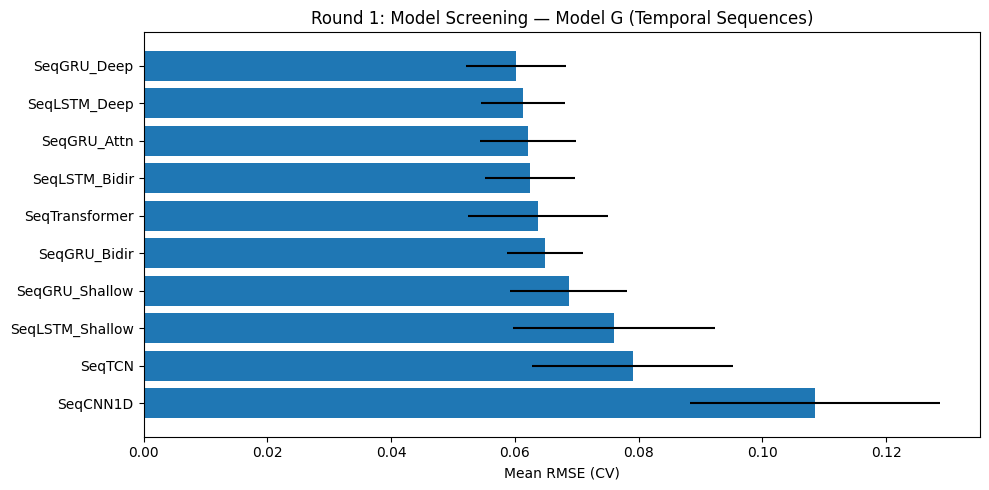

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(r1_results["model"], r1_results["mean_rmse"], xerr=r1_results["std_rmse"])
ax.set_xlabel("Mean RMSE (CV)")
ax.set_title("Round 1: Model Screening — Model G (Temporal Sequences)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
r1_summary = ckpt.load_round_summary(1)
if r1_summary:
    top7_names = r1_summary["top_names"]
else:
    top7_names = r1_results["model"].head(7).tolist()
print(f"Advancing to Round 2: {top7_names}")
eliminated = [n for n in r1_results["model"].tolist() if n not in top7_names]
print(f"Eliminated: {eliminated}")

Advancing to Round 2: ['SeqGRU_Deep', 'SeqLSTM_Deep', 'SeqGRU_Attn', 'SeqLSTM_Bidir', 'SeqTransformer', 'SeqGRU_Bidir', 'SeqGRU_Shallow']
Eliminated: ['SeqLSTM_Shallow', 'SeqTCN', 'SeqCNN1D']


## 5. Round 2 — Optuna (top 7, 10 trials each)

In [16]:
progress.round_header(2, "Optuna HP tuning (top 7, 10 trials each)")
slack.round_start(2, "Optuna HP tuning", len(top7_names))
r2_results = []
completed_r2 = ckpt.get_completed(2)
for idx, name in enumerate(top7_names, 1):
    if name in completed_r2:
        cp = completed_r2[name]
        r2_results.append({"model": name, "best_rmse": cp["rmse"], "best_params": cp["best_params"]})
        progress.log(f"{name} -- RESUMED from checkpoint (RMSE: {cp['rmse']:.6f})")
        continue
    progress.log(f"Tuning {name} ({idx}/{len(top7_names)})...")
    try:
        best_params, best_rmse = run_optuna_round_g(
            name, X_seq, y_seq, splitter, groups, n_trials=10)
        r2_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
        ckpt.save_checkpoint(2, name, best_rmse, best_params)
        progress.model_complete(name, 2, best_rmse)
        slack.architecture_done(name, 2, best_rmse)
    except Exception as e:
        progress.log(f"{name} FAILED in Round 2: {e}")
        slack.error(f"R2 {name}", str(e))

r2_df = pd.DataFrame(r2_results).sort_values("best_rmse").reset_index(drop=True)
ckpt.save_round_summary(2, r2_results, r2_df["model"].head(5).tolist())
slack.round_complete(2, f"Top 5: {r2_df['model'].head(5).tolist()}")
r2_df[["model", "best_rmse"]]

[Model G] [2026-04-29 01:29:02 UTC] ========== ROUND 2: Optuna HP tuning (top 7, 10 trials each) ==========


[Model G] [2026-04-29 01:29:03 UTC] Tuning SeqGRU_Deep (1/7)...


[Model G] [2026-04-29 01:31:06 UTC] SeqGRU_Deep trial 1/10 -- RMSE: 0.061707 (best: 0.061707)


[Model G] [2026-04-29 01:33:32 UTC] SeqGRU_Deep trial 2/10 -- RMSE: 0.060832 (best: 0.060832)


[Model G] [2026-04-29 01:35:53 UTC] SeqGRU_Deep trial 3/10 -- RMSE: 0.059643 (best: 0.059643)


...

[Model G] [2026-04-29 04:24:27 UTC] SeqGRU_Shallow trial 8/10 -- RMSE: 0.065682 (best: 0.061212)


[Model G] [2026-04-29 04:26:19 UTC] SeqGRU_Shallow trial 9/10 -- RMSE: 0.061725 (best: 0.061212)


[Model G] [2026-04-29 04:28:06 UTC] SeqGRU_Shallow trial 10/10 -- RMSE: 0.075491 (best: 0.061212)


[Model G] [2026-04-29 04:28:08 UTC] SeqGRU_Shallow Round 2 COMPLETE -- best RMSE: 0.061212


,model,best_rmse
0,SeqGRU_Deep,0.059586
1,SeqLSTM_Deep,0.059800
2,SeqGRU_Bidir,0.059939
3,SeqGRU_Attn,0.060451
4,SeqLSTM_Bidir,0.061098
5,SeqGRU_Shallow,0.061212
6,SeqTransformer,0.063065


In [17]:
r2_summary = ckpt.load_round_summary(2)
if r2_summary:
    top5_names = r2_summary["top_names"]
else:
    top5_names = r2_df["model"].head(5).tolist()
r2_best_params = {row["model"]: row["best_params"] for _, row in r2_df.iterrows() if "best_params" in row}
print(f"Advancing to Round 3: {top5_names}")

Advancing to Round 3: ['SeqGRU_Deep', 'SeqLSTM_Deep', 'SeqGRU_Bidir', 'SeqGRU_Attn', 'SeqLSTM_Bidir']


## 6. Round 3 — Final Tuning (top 5, 15 trials each)

In [18]:
progress.round_header(3, "Final tuning (top 5, 15 trials each)")
slack.round_start(3, "Final Optuna tuning", len(top5_names))
r3_results = []
completed_r3 = ckpt.get_completed(3)
for idx, name in enumerate(top5_names, 1):
    if name in completed_r3:
        cp = completed_r3[name]
        r3_results.append({"model": name, "best_rmse": cp["rmse"], "best_params": cp["best_params"]})
        progress.log(f"{name} -- RESUMED from checkpoint (RMSE: {cp['rmse']:.6f})")
        continue
    progress.log(f"Fine-tuning {name} ({idx}/{len(top5_names)})...")
    try:
        best_params, best_rmse = run_optuna_round_g(
            name, X_seq, y_seq, splitter, groups, n_trials=15)
        r3_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
        ckpt.save_checkpoint(3, name, best_rmse, best_params)
        progress.model_complete(name, 3, best_rmse)
        slack.architecture_done(name, 3, best_rmse)
    except Exception as e:
        progress.log(f"{name} FAILED in Round 3: {e}")
        slack.error(f"R3 {name}", str(e))

r3_df = pd.DataFrame(r3_results).sort_values("best_rmse").reset_index(drop=True)
r3_best_params = {row["model"]: row["best_params"] for _, row in r3_df.iterrows() if "best_params" in row}
ckpt.save_round_summary(3, r3_results, r3_df["model"].head(5).tolist())
slack.round_complete(3, f"Best: {r3_df.iloc[0]['model']} (RMSE: {r3_df.iloc[0]['best_rmse']:.6f})")
r3_df[["model", "best_rmse"]]

[Model G] [2026-04-29 04:28:10 UTC] ========== ROUND 3: Final tuning (top 5, 15 trials each) ==========


[Model G] [2026-04-29 04:28:10 UTC] Fine-tuning SeqGRU_Deep (1/5)...


[Model G] [2026-04-29 04:29:56 UTC] SeqGRU_Deep trial 1/15 -- RMSE: 0.059848 (best: 0.059848)


[Model G] [2026-04-29 04:31:40 UTC] SeqGRU_Deep trial 2/15 -- RMSE: 0.060072 (best: 0.059848)


[Model G] [2026-04-29 04:33:51 UTC] SeqGRU_Deep trial 3/15 -- RMSE: 0.060794 (best: 0.059848)


...

[Model G] [2026-04-29 07:43:43 UTC] SeqLSTM_Bidir trial 13/15 -- RMSE: 0.063596 (best: 0.060157)


[Model G] [2026-04-29 07:47:21 UTC] SeqLSTM_Bidir trial 14/15 -- RMSE: 0.061226 (best: 0.060157)


[Model G] [2026-04-29 07:50:45 UTC] SeqLSTM_Bidir trial 15/15 -- RMSE: 0.062053 (best: 0.060157)


[Model G] [2026-04-29 07:50:47 UTC] SeqLSTM_Bidir Round 3 COMPLETE -- best RMSE: 0.060157


,model,best_rmse
0,SeqLSTM_Deep,0.058256
1,SeqGRU_Deep,0.058942
2,SeqGRU_Attn,0.060026
3,SeqLSTM_Bidir,0.060157
4,SeqGRU_Bidir,0.061470


## 7. Test Set Evaluation (Per-Lap)

In [19]:
train_idx, test_idx = splitter.get_test_split(groups)
X_seq_train, X_seq_test = X_seq[train_idx], X_seq[test_idx]
y_train_full, y_test = y_seq[train_idx], y_seq[test_idx]
id_train, id_test = id_df.iloc[train_idx], id_df.iloc[test_idx]

print(f"Train: {X_seq_train.shape}, Test: {X_seq_test.shape}")
print(f"Test season(s): {sorted(set(groups[test_idx]))}")

Train: (73819, 10, 26), Test: (4787, 10, 26)
Test season(s): [np.int64(2024)]


In [20]:
final_results = []
for name in top5_names:
    params = reconstruct_params_g(name, r3_best_params[name])
    ws = params.pop("window_size", MAX_WINDOW)
    model_cls = MODEL_CLASSES_G[name]
    model = model_cls(**params, window_size=ws)

    X_tr_sliced = slice_window(X_seq_train, ws)
    X_te_sliced = slice_window(X_seq_test, ws)

    model.fit(X_tr_sliced, y_train_full)

    train_preds = model.predict(X_tr_sliced)
    train_rmse = np.sqrt(mean_squared_error(y_train_full, train_preds))

    test_preds = model.predict(X_te_sliced)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

    val_rmse = r3_df.loc[r3_df["model"] == name, "best_rmse"].values[0]

    final_results.append({
        "model": name,
        "train_rmse": train_rmse, "val_rmse": val_rmse,
        "test_rmse": test_rmse, "overfit_gap": test_rmse - val_rmse,
        "window_size": ws,
    })
    print(f"{name} (ws={ws}): train_rmse={train_rmse:.4f}, "
          f"val_rmse={val_rmse:.4f}, test_rmse={test_rmse:.4f}")

final_df = pd.DataFrame(final_results).sort_values("test_rmse").reset_index(drop=True)
final_df

SeqGRU_Deep (ws=3): train_rmse=0.0429, val_rmse=0.0589, test_rmse=0.0238


SeqLSTM_Deep (ws=3): train_rmse=0.0522, val_rmse=0.0583, test_rmse=0.0231


SeqGRU_Bidir (ws=3): train_rmse=0.0476, val_rmse=0.0615, test_rmse=0.0236


SeqGRU_Attn (ws=9): train_rmse=0.0411, val_rmse=0.0600, test_rmse=0.0226


SeqLSTM_Bidir (ws=7): train_rmse=0.0436, val_rmse=0.0602, test_rmse=0.0219


,model,train_rmse,val_rmse,test_rmse,overfit_gap,window_size
0,SeqLSTM_Bidir,0.043638,0.060157,0.021924,-0.038233,7
1,SeqGRU_Attn,0.041146,0.060026,0.022582,-0.037444,9
2,SeqLSTM_Deep,0.052153,0.058256,0.023077,-0.035179,3
3,SeqGRU_Bidir,0.047563,0.061470,0.023619,-0.037850,3
4,SeqGRU_Deep,0.042944,0.058942,0.023768,-0.035174,3


## 8. Sequence Simulation (2024 Test Races)

In [21]:
from f1_predictor.simulation.sequence_simulator import SequenceRaceSimulator
from f1_predictor.simulation.defaults import build_circuit_defaults
from f1_predictor.simulation.evaluation import evaluate_simulation
from f1_predictor.features.race_features import LOCATION_ALIASES

circuit_defaults = build_circuit_defaults(laps)

# Retrain best model on full training set
best_row = final_df.iloc[0]
best_model_name = best_row["model"]
best_ws = int(best_row["window_size"])
best_params = reconstruct_params_g(best_model_name, r3_best_params[best_model_name])
best_params.pop("window_size", None)
best_model = MODEL_CLASSES_G[best_model_name](**best_params, window_size=best_ws)
X_tr_sliced = slice_window(X_seq_train, best_ws)
best_model.fit(X_tr_sliced, y_train_full)

seq_sim = SequenceRaceSimulator(best_model, circuit_defaults, window_size=best_ws)
print(f"Sequence simulator: {best_model_name} (window={best_ws})")

Sequence simulator: SeqLSTM_Bidir (window=7)


In [22]:
test_races = races[races["season"] == 2024].copy()
test_race_list = test_races.groupby(
    ["season", "round", "event_name"]
).first().reset_index()

sim_results = []
for _, race_row in test_race_list.iterrows():
    event = race_row["event_name"]
    event_norm = LOCATION_ALIASES.get(event, event)

    if event_norm not in circuit_defaults:
        print(f"  Skipping {event} (no circuit data)")
        continue

    race_drivers = test_races[
        (test_races["season"] == race_row["season"])
        & (test_races["round"] == race_row["round"])
    ].copy()

    drivers_input = []
    actual_positions = {}
    for _, drv in race_drivers.iterrows():
        q1 = drv.get("q1_time_sec")
        q2 = drv.get("q2_time_sec")
        q3 = drv.get("q3_time_sec")
        q_times = [t for t in [q1, q2, q3] if pd.notna(t)]
        if not q_times or pd.isna(drv.get("grid_position")):
            continue
        drivers_input.append({
            "driver": drv["driver_abbrev"],
            "grid_position": int(drv["grid_position"]),
            "q1": q1 if pd.notna(q1) else None,
            "q2": q2 if pd.notna(q2) else None,
            "q3": q3 if pd.notna(q3) else None,
            "initial_tyre": "MEDIUM",
        })
        if pd.notna(drv.get("finish_position")):
            actual_positions[drv["driver_abbrev"]] = int(drv["finish_position"])

    if len(drivers_input) < 10:
        continue

    try:
        result = seq_sim.simulate(event_norm, drivers_input)
        for fr in result.final_results:
            if fr["driver"] in actual_positions:
                sim_results.append({
                    "event": event, "driver": fr["driver"],
                    "predicted_pos": fr["position"],
                    "actual_pos": actual_positions[fr["driver"]],
                })
        print(f"  {event}: simulated {len(drivers_input)} drivers")
    except Exception as e:
        print(f"  {event}: failed — {e}")

sim_df = pd.DataFrame(sim_results)
print(f"\nSimulation results: {len(sim_df)} driver-race predictions")

  Bahrain Grand Prix: simulated 20 drivers


  Emilia Romagna Grand Prix: simulated 19 drivers


  Hungarian Grand Prix: simulated 20 drivers


  Mexico City Grand Prix: simulated 20 drivers

Simulation results: 79 driver-race predictions


In [23]:
if len(sim_df) > 0:
    sim_metrics = evaluate_simulation(sim_df)
    print("=" * 60)
    print("MODEL G — SEQUENCE SIMULATION (2024)")
    print("=" * 60)
    for k, v in sim_metrics.items():
        print(f"  {k:20s}: {v}")

MODEL G — SEQUENCE SIMULATION (2024)
  position_rmse       : 3.6612925710927886
  position_mae        : 2.721518987341772
  r2                  : 0.5953714451538015
  within_1            : 32.91139240506329
  within_3            : 77.21518987341773
  within_5            : 87.34177215189874
  spearman_mean       : 0.7993107769423559
  n_races             : 4


## 9. Save Artifacts

In [24]:
ID_COLS_SEQ = ["season", "round", "driver_abbrev", "lap_number"]

for name in top5_names:
    params = reconstruct_params_g(name, r3_best_params[name])
    ws = params.pop("window_size", MAX_WINDOW)
    model_cls = MODEL_CLASSES_G[name]
    model = model_cls(**params, window_size=ws)

    X_tr_s = slice_window(X_seq_train, ws)
    X_te_s = slice_window(X_seq_test, ws)
    model.fit(X_tr_s, y_train_full)

    # Training predictions
    train_preds = model.predict(X_tr_s)
    out = id_train.copy()
    out["y_true"] = y_train_full
    out["y_pred"] = train_preds
    fname = f"model_G_{name}_Training.parquet"
    uri = save_training_parquet(out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")

    # Test predictions
    test_preds = model.predict(X_te_s)
    out = id_test.copy()
    out["y_true"] = y_test
    out["y_pred"] = test_preds
    fname = f"model_G_{name}_Test.parquet"
    uri = save_training_parquet(out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")

    # OOF validation predictions
    oof_preds = np.full(len(y_seq), np.nan)
    for tr_idx, va_idx in splitter.split(groups):
        import sklearn.base
        fold_model = sklearn.base.clone(model)
        X_tr_fold = slice_window(X_seq[tr_idx], ws)
        fold_model.fit(X_tr_fold, y_seq[tr_idx])
        X_va_fold = slice_window(X_seq[va_idx], ws)
        oof_preds[va_idx] = fold_model.predict(X_va_fold)

    val_mask = ~np.isnan(oof_preds)
    val_out = id_df.loc[val_mask].copy()
    val_out["y_true"] = y_seq[val_mask]
    val_out["y_pred"] = oof_preds[val_mask]
    fname = f"model_G_{name}_Validation.parquet"
    uri = save_training_parquet(val_out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")

    save_model_pkl(model, "G", name)

print("\nDone! All Model G artifacts saved.")

  Saved model_G_SeqGRU_Deep_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqGRU_Deep_Training.parquet
  Saved model_G_SeqGRU_Deep_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqGRU_Deep_Test.parquet


  Saved model_G_SeqGRU_Deep_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqGRU_Deep_Validation.parquet
  Saved Model_G_SeqGRU_Deep.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_G_SeqGRU_Deep.pkl


  Saved model_G_SeqLSTM_Deep_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqLSTM_Deep_Training.parquet
  Saved model_G_SeqLSTM_Deep_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqLSTM_Deep_Test.parquet


  Saved model_G_SeqLSTM_Deep_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqLSTM_Deep_Validation.parquet
  Saved Model_G_SeqLSTM_Deep.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_G_SeqLSTM_Deep.pkl


  Saved model_G_SeqGRU_Bidir_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqGRU_Bidir_Training.parquet
  Saved model_G_SeqGRU_Bidir_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqGRU_Bidir_Test.parquet


...

  Saved model_G_SeqGRU_Attn_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqGRU_Attn_Validation.parquet


  Saved Model_G_SeqGRU_Attn.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_G_SeqGRU_Attn.pkl


  Saved model_G_SeqLSTM_Bidir_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqLSTM_Bidir_Training.parquet
  Saved model_G_SeqLSTM_Bidir_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqLSTM_Bidir_Test.parquet


  Saved model_G_SeqLSTM_Bidir_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_G_SeqLSTM_Bidir_Validation.parquet


  Saved Model_G_SeqLSTM_Bidir.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_G_SeqLSTM_Bidir.pkl

Done! All Model G artifacts saved.


## Summary

In [25]:
print("=" * 60)
print("MODEL G (TEMPORAL SEQUENCE) TRAINING COMPLETE")
print("=" * 60)
print(f"\nPer-lap evaluation (top 5, sorted by test RMSE):")
for _, row in final_df.iterrows():
    print(f"  {row['model']:25s} ws={int(row['window_size'])} "
          f"test_rmse={row['test_rmse']:.6f} gap={row['overfit_gap']:.6f}")

if len(sim_df) > 0:
    print(f"\nSequence simulation (2024):")
    print(f"  Position RMSE: {sim_metrics['position_rmse']:.4f}")
    print(f"  Spearman:      {sim_metrics['spearman_mean']:.4f}")
    print(f"  Within-3:      {sim_metrics['within_3']:.1f}%")
print(f"\nArtifacts saved to:")
print(f"  Predictions: {TRAINING_DIR}")
print(f"  Models: {MODEL_DIR}")

best_name = final_df.iloc[0]["model"]
best_rmse = final_df.iloc[0]["test_rmse"]
progress.log(f"MODEL G TRAINING COMPLETE -- best: {best_name} (RMSE: {best_rmse:.6f})")
slack.model_complete(best_name, best_rmse)

MODEL G (TEMPORAL SEQUENCE) TRAINING COMPLETE

Per-lap evaluation (top 5, sorted by test RMSE):
  SeqLSTM_Bidir             ws=7 test_rmse=0.021924 gap=-0.038233
  SeqGRU_Attn               ws=9 test_rmse=0.022582 gap=-0.037444
  SeqLSTM_Deep              ws=3 test_rmse=0.023077 gap=-0.035179
  SeqGRU_Bidir              ws=3 test_rmse=0.023619 gap=-0.037850
  SeqGRU_Deep               ws=3 test_rmse=0.023768 gap=-0.035174

Sequence simulation (2024):
  Position RMSE: 3.6613
  Spearman:      0.7993
  Within-3:      77.2%

Artifacts saved to:
  Predictions: data/training
  Models: data/raw/model
[Model G] [2026-04-29 08:17:37 UTC] MODEL G TRAINING COMPLETE -- best: SeqLSTM_Bidir (RMSE: 0.021924)
